<a href="https://colab.research.google.com/github/sec23cb084-stack/ASTMA-Instagram/blob/main/Astma_Instagram.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS
import re

# Load dataset
df = pd.read_csv("influencers_categories.csv")

# Clean column names
df.columns = df.columns.str.strip()

print("Columns in Dataset:")
print(df.columns)



Columns in Dataset:
Index(['Name', 'Category', 'Platform', 'Followers', 'Country'], dtype='object')


In [31]:
engagement_col = None

for col in df.columns:
    if "engagement" in col.lower():
        engagement_col = col
        break

print("\nDetected Engagement Column:", engagement_col)



Detected Engagement Column: None


In [32]:
# Convert Followers to Numeric
# ------------------------------------------

df['Followers'] = (
    df['Followers']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.replace('M', '000000', regex=False)
    .str.replace('K', '000', regex=False)
)

df['Followers'] = pd.to_numeric(
    df['Followers'],
    errors='coerce'
)


In [33]:
# Convert Engagement to Numeric
# ------------------------------------------

if engagement_col is not None:

    df[engagement_col] = (
        df[engagement_col]
        .astype(str)
        .str.replace(',', '', regex=False)
        .str.replace('M', '000000', regex=False)
        .str.replace('K', '000', regex=False)
    )

    df[engagement_col] = pd.to_numeric(
        df[engagement_col],
        errors='coerce'
    )


In [34]:
# Top 5 Influencers
# ------------------------------------------

top5 = df.sort_values(
    by='Followers',
    ascending=False
).head(5)

print("\nTop 5 Influencers:")
print(top5[['Name', 'Followers', 'Category']])



Top 5 Influencers:
                Name  Followers                Category
1  Cristiano Ronaldo  650000000                  Player
2       Lionel Messi  500000000                  Player
0        Virat Kohli  270000000                  Player
4           Khan Sir   24000000  Educational Influencer
6        Drishti IAS   20000000  Educational Influencer


In [35]:
# Least Followers
# ------------------------------------------

least = df.loc[df['Followers'].idxmin()]

print("\nLeast Followed Influencer:")
print(least[['Name', 'Followers', 'Category']])



Least Followed Influencer:
Name             Luke Coutinho
Followers              2000000
Category     Health Influencer
Name: 9, dtype: object


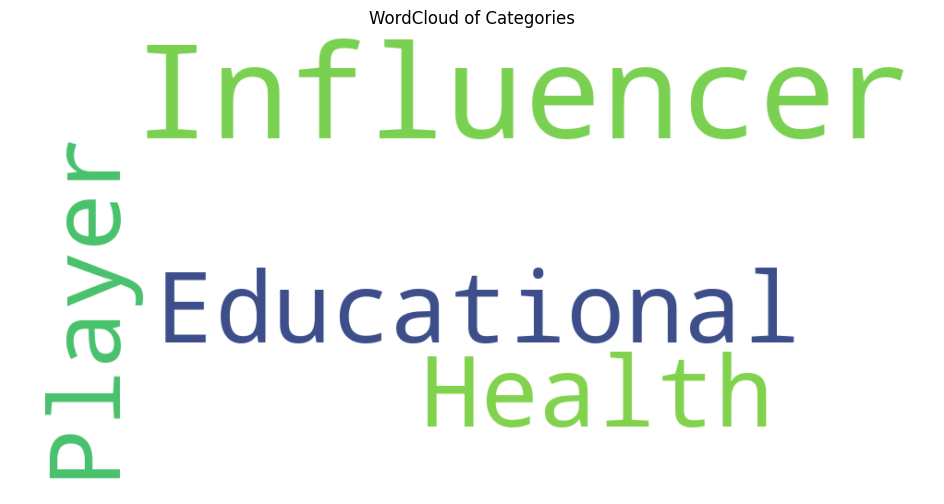

In [36]:
# WordCloud
# ------------------------------------------

text = " ".join(df['Category'].dropna().astype(str))

text = re.sub(r'[^A-Za-z ]', '', text)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    stopwords=set(STOPWORDS)
).generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud of Categories")
plt.show()


Category Wise Count:
Category
Educational Influencer    4
Health Influencer         4
Player                    4
Name: Name, dtype: int64


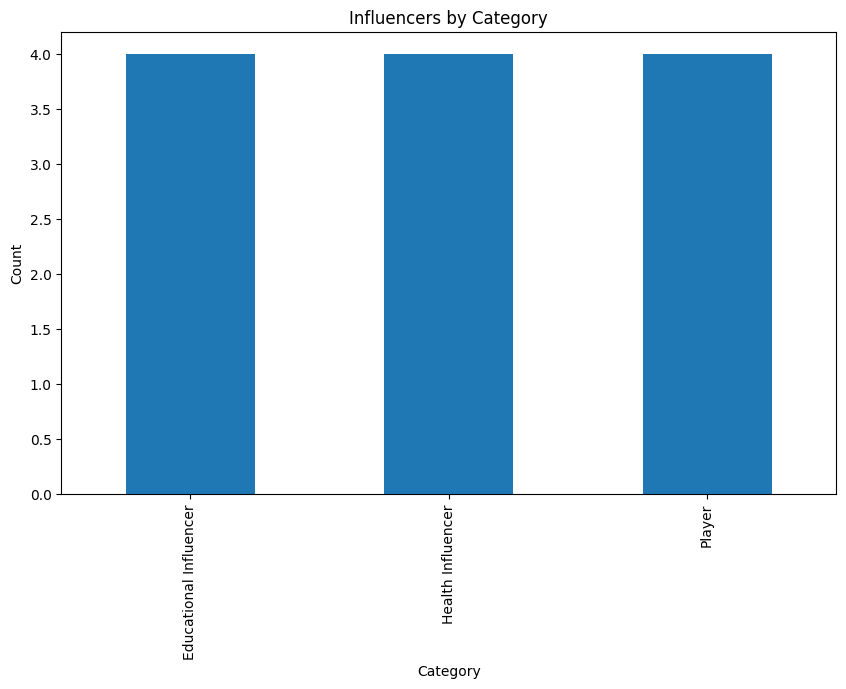

In [37]:
# Category Count
# ------------------------------------------

category_group = df.groupby('Category')['Name'].count()

print("\nCategory Wise Count:")
print(category_group)

plt.figure(figsize=(10,6))

category_group.sort_values(
    ascending=False
).plot(kind='bar')

plt.title("Influencers by Category")
plt.xlabel("Category")
plt.ylabel("Count")

plt.show()


In [38]:
# Scatter Plot
# ------------------------------------------

if engagement_col is not None:

    plt.figure(figsize=(10,6))

    sns.scatterplot(
        x='Followers',
        y=engagement_col,
        hue='Category',
        data=df
    )

    plt.title("Followers vs Engagement")

    plt.show()

else:
    print("\nNo Engagement Column Found")


No Engagement Column Found
